# 01 · Entendimento dos dados

**Previsão de atraso de entrega no e-commerce brasileiro (Olist)** · Notebook 1 de 3

Este notebook estabelece as fundações do projeto: o problem statement formal, o mapa relacional das 9 tabelas com verificações executáveis de granularidade, a definição exata do alvo e, no centro, a **auditoria de vazamento**: a classificação de cada coluna como permitida ou banida segundo um único critério, *ser conhecida no momento da compra*. Inclui também a validação dedicada de `shipping_limit_date` e a verificação das armadilhas de integridade que afetam os joins da tabela mestra.

O dicionário de dados completo, construído por inspeção direta dos CSVs, está em [`data/data_dictionary.md`](../data/data_dictionary.md).

## 1. Problem statement

No momento em que um cliente conclui uma compra, a plataforma exibe uma data prometida de entrega (`order_estimated_delivery_date`). Quando a entrega ocorre depois dessa data, o cliente vive a pior experiência do funil logístico, e a empresa só fica sabendo depois do dano.

**Formulação:** classificação binária supervisionada. Para cada **pedido** (`order_id`), prever **no momento da compra** a probabilidade de a entrega ocorrer após a data prometida.

- **População:** pedidos com `order_status = "delivered"` e data de entrega registrada.
- **Alvo:** `is_late = 1` se `date(order_delivered_customer_date) > date(order_estimated_delivery_date)`. A comparação é entre **datas**, não timestamps, porque a estimativa é sempre registrada à meia-noite (verificado na seção 5).
- **Unidade de análise:** o pedido, porque é o que o cliente experimenta; os itens são agregados (soma de frete, peso total, nº de itens, nº de vendedores).
- **Restrições metodológicas:** (i) só entram como features colunas conhecidas no momento da compra, formalizado na auditoria da seção 6; (ii) validação por split temporal, nunca aleatório, porque em produção o modelo prevê o futuro com dados do passado.
- **Fora do escopo (limitações documentadas):** pedidos cancelados ou nunca entregues; previsão da magnitude do atraso (regressão) fica como próximo passo.

**Uso de negócio:** com uma probabilidade de atraso disponível no instante da compra, a operação pode notificar proativamente os clientes de alto risco e priorizar pedidos críticos, transformando a previsão em ação operacional.

## 2. Setup e carga das 9 tabelas

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Project root: the notebook runs from notebooks/, scripts may run from the root.
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
RAW = ROOT / "data" / "raw"

pd.set_option("display.max_columns", 60)
print(f"pandas {pd.__version__} · numpy {np.__version__}")

pandas 3.0.3 · numpy 2.4.6


In [2]:
# Single-series charts throughout: one accent hue, recessive grid and axes.
ACCENT = "#2563eb"
GRAY = "#6b7280"

plt.rcParams.update(
    {
        "figure.figsize": (9, 3.8),
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "axes.grid.axis": "y",
        "grid.color": "#e5e7eb",
        "grid.linewidth": 0.8,
        "axes.edgecolor": GRAY,
        "axes.labelcolor": "#374151",
        "xtick.color": GRAY,
        "ytick.color": GRAY,
        "axes.titlecolor": "#111827",
        "axes.titlelocation": "left",
        "axes.titleweight": "bold",
    }
)

In [3]:
FILES = {
    "orders": "olist_orders_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "order_payments": "olist_order_payments_dataset.csv",
    "order_reviews": "olist_order_reviews_dataset.csv",
    "customers": "olist_customers_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "products": "olist_products_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}
dfs = {name: pd.read_csv(RAW / fname) for name, fname in FILES.items()}

overview = pd.DataFrame(
    {
        "linhas": {k: len(v) for k, v in dfs.items()},
        "colunas": {k: v.shape[1] for k, v in dfs.items()},
    }
).sort_values("linhas", ascending=False)
overview

,linhas,colunas
geolocation,1000163,5
order_items,112650,7
order_payments,103886,5
orders,99441,8
customers,99441,5
order_reviews,99224,7
products,32951,9
sellers,3095,4
category_translation,71,2


In [4]:
orders = dfs["orders"].copy()
TS_COLS = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for col in TS_COLS:
    orders[col] = pd.to_datetime(orders[col])
orders.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04


## 3. Mapa relacional e granularidade (verificações executáveis)

```text
customers ─1:1─ orders ─1:N─ order_items ─N:1─ products ─N:1─ category_translation
                  │                └─────N:1── sellers
                  ├─1:N─ order_payments
                  └─1:N─ order_reviews
geolocation: SEM chave; liga a customers/sellers pelo prefixo de CEP,
somente APÓS agregação para um centroide por prefixo (seção 8)
```

A armadilha central do schema: **`customer_id` é único por PEDIDO**, não por pessoa (a pessoa é `customer_unique_id`). Portanto `orders ↔ customers` é um join 1:1, não 1:N.

Em vez de confiar na documentação do Kaggle, cada premissa de chave vira uma verificação executável. As duas falhas esperadas (`review_id` e `geolocation`) são exatamente as armadilhas documentadas no dicionário de dados.

In [5]:
checks = {
    "orders: order_id único": dfs["orders"]["order_id"].is_unique,
    "customers: customer_id único": dfs["customers"]["customer_id"].is_unique,
    "orders ↔ customers: join 1:1": bool(
        dfs["orders"]["customer_id"].is_unique
        and dfs["orders"]["customer_id"].isin(dfs["customers"]["customer_id"]).all()
    ),
    "order_items: (order_id, order_item_id) único": bool(
        not dfs["order_items"].duplicated(["order_id", "order_item_id"]).any()
    ),
    "products: product_id único": dfs["products"]["product_id"].is_unique,
    "sellers: seller_id único": dfs["sellers"]["seller_id"].is_unique,
    "order_payments: (order_id, payment_sequential) único": bool(
        not dfs["order_payments"].duplicated(["order_id", "payment_sequential"]).any()
    ),
    "order_reviews: review_id único (falha esperada)": dfs["order_reviews"]["review_id"].is_unique,
    "geolocation: alguma chave única (falha esperada)": bool(
        not dfs["geolocation"]
        .duplicated(["geolocation_zip_code_prefix", "geolocation_lat", "geolocation_lng"])
        .any()
    ),
}
pd.Series(checks, name="passa").to_frame()

,passa
orders: order_id único,True
customers: customer_id único,True
orders ↔ customers: join 1:1,True
"order_items: (order_id, order_item_id) único",True
products: product_id único,True
sellers: seller_id único,True
"order_payments: (order_id, payment_sequential) único",True
order_reviews: review_id único (falha esperada),False
geolocation: alguma chave única (falha esperada),False


In [6]:
geo = dfs["geolocation"]
per_prefix = geo.groupby("geolocation_zip_code_prefix").size()
print(f"geolocation: {len(geo):,} linhas para {per_prefix.size:,} prefixos de CEP")
print(f"linhas por prefixo: mediana {per_prefix.median():.0f}, máximo {per_prefix.max():,}")

reviews = dfs["order_reviews"]
reviews_per_order = reviews.groupby("order_id").size()
print(f"reviews: {reviews['review_id'].duplicated().sum():,} review_id duplicados")
print(f"pedidos com mais de um review: {(reviews_per_order > 1).sum():,}")

geolocation: 1,000,163 linhas para 19,015 prefixos de CEP
linhas por prefixo: mediana 29, máximo 1,146
reviews: 814 review_id duplicados
pedidos com mais de um review: 547


Consequências práticas, tratadas nas seções 6 e 8: `geolocation` só entra agregada (um centroide por prefixo), senão qualquer merge multiplica linhas; `order_reviews` exige deduplicação se for usada na EDA, e como feature está banida de qualquer forma (posterior à entrega).

## 4. Volumetria e período

In [7]:
period = orders["order_purchase_timestamp"].agg(["min", "max"])
print(f"Período de compras: {period['min']:%Y-%m-%d} a {period['max']:%Y-%m-%d}")
orders["order_status"].value_counts().to_frame("pedidos")

Período de compras: 2016-09-04 a 2018-10-17


,pedidos
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


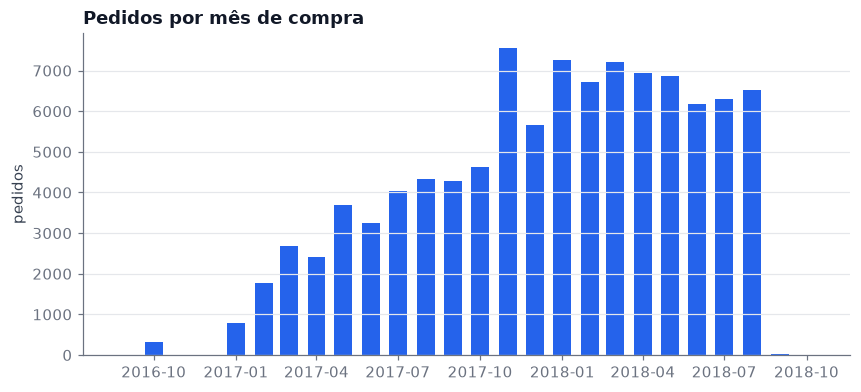

In [8]:
monthly = orders.set_index("order_purchase_timestamp").resample("MS").size()

fig, ax = plt.subplots()
ax.bar(monthly.index, monthly.values, width=20, color=ACCENT)
ax.set_title("Pedidos por mês de compra")
ax.set_ylabel("pedidos")
plt.show()

Três leituras que orientam o desenho do projeto:

- **2016 é residual** (poucas centenas de pedidos, com um buraco em dez/2016). Permanece no treino: não distorce e alimenta o histórico expansivo dos vendedores.
- O degrau de **nov/2017 é a Black Friday**, primeira candidata a padrão sazonal de atraso (EDA, notebook 02).
- A queda abrupta no fim da série não é queda de demanda, é **censura da extração** (pedidos recentes ainda não entregues), quantificada na seção 9.

## 5. Definição do alvo

A população são os pedidos `delivered` com data de entrega registrada. A comparação correta é entre **datas**, e a célula abaixo prova o porquê: a estimativa é sempre registrada à meia-noite, então comparar timestamps rotularia como atraso qualquer entrega feita no próprio dia prometido depois de 00:00.

In [9]:
delivered = orders[orders["order_status"] == "delivered"].copy()
n_no_date = int(delivered["order_delivered_customer_date"].isna().sum())
delivered = delivered.dropna(subset=["order_delivered_customer_date"])

print(f"pedidos delivered: {len(delivered) + n_no_date:,}")
print(f"delivered sem data de entrega (excluídos do escopo): {n_no_date}")
print(f"população final: {len(delivered):,}")

est = delivered["order_estimated_delivery_date"]
print(f"estimativa sempre à meia-noite? {bool((est.dt.normalize() == est).all())}")

pedidos delivered: 96,478
delivered sem data de entrega (excluídos do escopo): 8
população final: 96,470
estimativa sempre à meia-noite? True


In [10]:
real_date = delivered["order_delivered_customer_date"].dt.normalize()
delivered["is_late"] = (real_date > delivered["order_estimated_delivery_date"]).astype(int)

naive = delivered["order_delivered_customer_date"] > delivered["order_estimated_delivery_date"]
n_correct, n_naive = delivered["is_late"].sum(), int(naive.sum())
print(f"taxa de atraso comparando DATAS (correta):    {delivered['is_late'].mean():.2%} ({n_correct:,} pedidos)")
print(f"taxa comparando TIMESTAMPS (ingênua):         {naive.mean():.2%} ({n_naive:,} pedidos)")
print(f"pedidos que a comparação ingênua rotularia errado: {n_naive - n_correct:,}")

taxa de atraso comparando DATAS (correta):    6.77% (6,534 pedidos)
taxa comparando TIMESTAMPS (ingênua):         8.11% (7,826 pedidos)
pedidos que a comparação ingênua rotularia errado: 1,292


Dois fatos ficam estabelecidos:

1. **A classe positiva é rara (~6,8%).** O problema é desbalanceado; acurácia fica proibida como métrica principal (um modelo que sempre diz "sem atraso" acertaria ~93%). A seleção de modelo usará AUC-PR, e o desbalanceamento será tratado com pesos de classe, sem reamostragem sintética.
2. **A definição do alvo é uma decisão, não um detalhe.** A comparação ingênua por timestamp inflaria a taxa rotulando errado milhares de pedidos entregues no próprio dia prometido.

## 6. Auditoria de vazamento

**Regra única:** uma coluna só pode ser feature se seu valor é conhecido **no momento em que o cliente conclui a compra**. Tudo que o ciclo de vida do pedido preenche depois (aprovação, postagem, entrega, review) é banido: em produção esses campos estariam vazios no instante da previsão, e no treino eles contrabandeiam a resposta.

A tabela abaixo é o **contrato** deste projeto: os notebooks 02 e 03 só podem consumir colunas `PERMITIDA` (e derivadas delas). O teste de sanidade planejado para o notebook 03 (treinar com alvo embaralhado e obter AUC ≈ 0,5) verifica que o contrato foi cumprido.

In [11]:
audit_rows = [
    # orders
    ("orders", "order_id", "CHAVE", "identificador do pedido"),
    ("orders", "customer_id", "CHAVE", "liga ao cadastro do cliente (1:1)"),
    ("orders", "order_status", "BANIDA", "evolui após a compra; define a POPULAÇÃO (delivered), nunca é feature"),
    ("orders", "order_purchase_timestamp", "PERMITIDA", "o instante da previsão; origem de mês, dia da semana"),
    ("orders", "order_approved_at", "BANIDA", "preenchida após a compra (aprovação do pagamento)"),
    ("orders", "order_delivered_carrier_date", "BANIDA", "posterior à compra (postagem)"),
    ("orders", "order_delivered_customer_date", "ALVO", "define o alvo; jamais feature"),
    ("orders", "order_estimated_delivery_date", "PERMITIDA", "exibida ao cliente no checkout; origem da janela prometida em dias"),
    # order_items
    ("order_items", "order_id / order_item_id", "CHAVE", "grão item do pedido"),
    ("order_items", "product_id / seller_id", "CHAVE", "ligam a produto e vendedor"),
    ("order_items", "price", "PERMITIDA", "definido no checkout"),
    ("order_items", "freight_value", "PERMITIDA", "definido no checkout; origem da razão frete/preço"),
    ("order_items", "shipping_limit_date", "VALIDADA E EXCLUÍDA", "em tese definida no checkout; validação na seção 7, excluída por prudência"),
    # order_payments
    ("order_payments", "payment_type / installments / value", "PERMITIDA", "escolhidos pelo cliente no checkout"),
    ("order_payments", "payment_sequential", "PERMITIDA", "ordem dos meios de pagamento, definida no checkout"),
    # order_reviews
    ("order_reviews", "todas as colunas", "BANIDA", "reviews são posteriores à ENTREGA; 100% vazamento; uso apenas descritivo na EDA"),
    # products
    ("products", "product_category_name", "PERMITIDA", "atributo estático do catálogo"),
    ("products", "peso e dimensões (4 colunas)", "PERMITIDA", "atributos estáticos; origem de peso e volume do pedido"),
    ("products", "fotos e descrição (3 colunas)", "PERMITIDA", "atributos estáticos, valor preditivo provavelmente baixo"),
    # customers
    ("customers", "customer_unique_id", "CHAVE", "identifica a pessoa entre pedidos"),
    ("customers", "zip prefix / cidade / UF", "PERMITIDA", "endereço de entrega informado na compra; origem de UF de destino e distância"),
    # sellers
    ("sellers", "zip prefix / cidade / UF", "PERMITIDA", "cadastro do vendedor; origem da distância vendedor→cliente"),
    # geolocation
    ("geolocation", "lat / lng", "PERMITIDA", "estáticas; entram como centroide por prefixo de CEP (seção 8)"),
    # derivadas
    ("derivada", "taxa histórica de atraso do vendedor", "PERMITIDA COM CUIDADO", "média expansiva DESLOCADA (expanding().mean().shift(1)) por vendedor: só pedidos anteriores à compra"),
    ("derivada", "distância haversine vendedor→cliente", "PERMITIDA", "derivada de cadastros estáticos"),
]
audit = pd.DataFrame(audit_rows, columns=["tabela", "coluna", "status", "motivo"])

with pd.option_context("display.max_rows", 100, "display.max_colwidth", 120):
    display(audit)

audit["status"].value_counts().to_frame("colunas/grupos")

,tabela,coluna,status,motivo
0,orders,order_id,CHAVE,identificador do pedido
1,orders,customer_id,CHAVE,liga ao cadastro do cliente (1:1)
2,orders,order_status,BANIDA,"evolui após a compra; define a POPULAÇÃO (delivered), nunca é feature"
3,orders,order_purchase_timestamp,PERMITIDA,"o instante da previsão; origem de mês, dia da semana"
4,orders,order_approved_at,BANIDA,preenchida após a compra (aprovação do pagamento)
5,orders,order_delivered_carrier_date,BANIDA,posterior à compra (postagem)
6,orders,order_delivered_customer_date,ALVO,define o alvo; jamais feature
7,orders,order_estimated_delivery_date,PERMITIDA,exibida ao cliente no checkout; origem da janela prometida em dias
8,order_items,order_id / order_item_id,CHAVE,grão item do pedido
9,order_items,product_id / seller_id,CHAVE,ligam a produto e vendedor


,colunas/grupos
status,
PERMITIDA,13
CHAVE,5
BANIDA,4
ALVO,1
VALIDADA E EXCLUÍDA,1
PERMITIDA COM CUIDADO,1


Destaques do contrato:

- **A feature mais preditiva é também a mais perigosa.** A taxa histórica de atraso do vendedor só é legítima com a média expansiva deslocada: para o pedido feito em $t$, contam apenas os pedidos do mesmo vendedor concluídos antes de $t$. Sem o deslocamento, o próprio pedido (e o futuro do vendedor) vazaria para dentro da feature.
- **`order_status` tem papel duplo e nenhum deles é feature:** filtra a população no treino e é desconhecido ("created") no momento da previsão em produção.
- **Reviews são o caso extremo:** existem por causa da entrega, então qualquer uso preditivo é vazamento por construção.

## 7. Validação dedicada: `shipping_limit_date`

`shipping_limit_date` é a data-limite para o vendedor postar o item. Em tese ela é **definida no checkout** (deriva do SLA do vendedor), o que a tornaria uma feature permitida, e potencialmente boa: a folga entre compra e limite de postagem mede a agressividade do compromisso logístico.

A validação abaixo verifica se o comportamento observado é compatível com essa tese: o limite deve ser posterior à compra e a folga deve ter distribuição estável e plausível.

In [12]:
items = dfs["order_items"].copy()
items["shipping_limit_date"] = pd.to_datetime(items["shipping_limit_date"])
items = items.merge(orders[["order_id", "order_purchase_timestamp"]], on="order_id", how="left")

slack_days = (
    (items["shipping_limit_date"] - items["order_purchase_timestamp"]).dt.total_seconds() / 86400
)
n_violations = int((slack_days < 0).sum())
print(f"itens avaliados: {len(items):,}")
print(f"limite ANTERIOR à compra (violações da tese): {n_violations:,} ({n_violations / len(items):.4%})")
slack_days.describe().round(2).to_frame("folga em dias (shipping_limit − compra)")

itens avaliados: 112,650
limite ANTERIOR à compra (violações da tese): 0 (0.0000%)


,folga em dias (shipping_limit − compra)
count,112650.00
mean,6.64
std,7.07
min,2.00
25%,5.01
50%,6.01
75%,7.19
max,1056.04


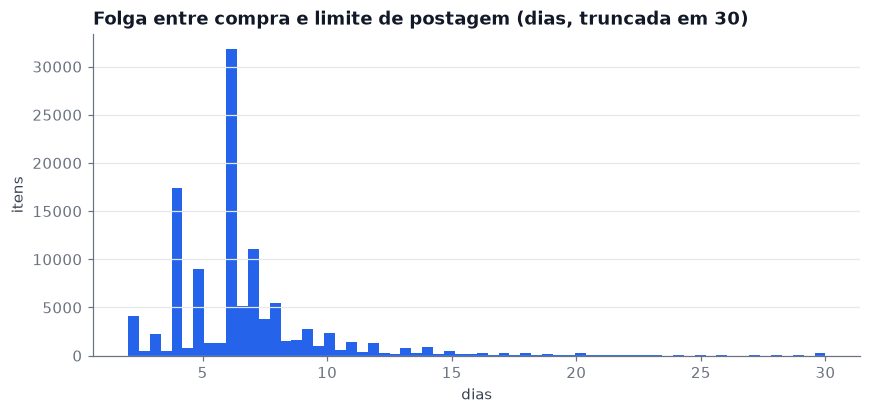

In [13]:
fig, ax = plt.subplots()
ax.hist(slack_days.clip(-2, 30), bins=64, color=ACCENT)
ax.set_title("Folga entre compra e limite de postagem (dias, truncada em 30)")
ax.set_xlabel("dias")
ax.set_ylabel("itens")
plt.show()

**Decisão (registrada antes da modelagem): a coluna fica FORA do modelo.**

O ponto não é o resultado numérico da validação, é o que ela **não consegue provar**. O dataset é um snapshot: não há como demonstrar que `shipping_limit_date` nunca é atualizada depois da compra (por exemplo, em repostagens ou renegociações de prazo). Se ela for atualizada em qualquer fração dos casos, carregaria informação do futuro exatamente nos pedidos problemáticos, os mesmos que queremos prever.

A assimetria de risco decide: o ganho de métrica é marginal (a janela prometida, esta sim exibida ao cliente, já captura o compromisso de prazo), e o custo de um vazamento silencioso seria a credibilidade do modelo inteiro. Candidata em tese permitida, validada nos dados, e mesmo assim excluída por decisão consciente.

## 8. Armadilhas de integridade para a tabela mestra

Cada verificação abaixo corresponde a um tratamento planejado no `src/data_prep.py` (etapa 2).

In [14]:
# Brazil bounding box (includes oceanic islands).
LAT_BOUNDS = (-33.75, 5.30)
LNG_BOUNDS = (-74.00, -28.80)

outside = ~(
    geo["geolocation_lat"].between(*LAT_BOUNDS)
    & geo["geolocation_lng"].between(*LNG_BOUNDS)
)
print(f"coordenadas fora da caixa do Brasil: {outside.sum():,} ({outside.mean():.4%})")
print(
    f"extremos observados: lat [{geo['geolocation_lat'].min():.1f}, {geo['geolocation_lat'].max():.1f}] · "
    f"lng [{geo['geolocation_lng'].min():.1f}, {geo['geolocation_lng'].max():.1f}]"
)

coordenadas fora da caixa do Brasil: 31 (0.0031%)
extremos observados: lat [-36.6, 45.1] · lng [-101.5, 121.1]


In [15]:
cust_prefix = set(dfs["customers"]["customer_zip_code_prefix"])
sell_prefix = set(dfs["sellers"]["seller_zip_code_prefix"])
geo_prefix = set(geo["geolocation_zip_code_prefix"])
print(f"prefixos de CEP de clientes sem geolocation: {len(cust_prefix - geo_prefix)}")
print(f"prefixos de CEP de vendedores sem geolocation: {len(sell_prefix - geo_prefix)}")

products = dfs["products"]
dim_cols = ["product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]
print(f"produtos sem categoria: {products['product_category_name'].isna().sum()}")
print(f"produtos sem peso/dimensões: {products[dim_cols].isna().any(axis=1).sum()}")

cats = set(products["product_category_name"].dropna())
translated = set(dfs["category_translation"]["product_category_name"])
print(f"categorias sem tradução: {sorted(cats - translated)}")

paid = dfs["orders"]["order_id"].isin(dfs["order_payments"]["order_id"])
print(f"pedidos sem registro de pagamento: {int((~paid).sum())}")

sellers_per_order = dfs["order_items"].groupby("order_id")["seller_id"].nunique()
n_multi = int((sellers_per_order > 1).sum())
print(f"pedidos com mais de um vendedor: {n_multi:,} ({n_multi / len(sellers_per_order):.2%})")

prefixos de CEP de clientes sem geolocation: 157
prefixos de CEP de vendedores sem geolocation: 7
produtos sem categoria: 610
produtos sem peso/dimensões: 2
categorias sem tradução: ['pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos']


pedidos sem registro de pagamento: 1
pedidos com mais de um vendedor: 1,278 (1.30%)


Tratamentos planejados, um por armadilha:

| Armadilha | Tratamento na etapa 2 |
|---|---|
| Coordenadas fora do Brasil | Filtrar pela caixa geográfica ANTES do centroide (mediana de lat/lng por prefixo) |
| `geolocation` sem chave | Agregar para 1 linha por prefixo antes de qualquer join (senão o merge multiplica linhas) |
| Prefixos sem geolocation | Distância fica nula → imputar e sinalizar com flag |
| Produtos sem categoria | Categoria "desconhecida" explícita |
| Produtos sem peso/dimensões | Imputação simples e flag (2 casos, impacto nulo) |
| Categorias sem tradução | Manter o nome em português (a tradução é cosmética) |
| Pedido sem pagamento | 1 caso; features de pagamento nulas com flag |
| Pedidos multi-vendedor | Risco do pedido = MÁXIMO das taxas dos vendedores (elo mais fraco); `n_sellers` como feature |

Auditoria de linhas antes/depois de cada join fica como regra do `src/data_prep.py`.

## 9. Cobertura de entrega no fim do período (viés de sobrevivência)

O dataset é um snapshot de outubro/2018. Pedidos comprados perto do fim só aparecem como `delivered` se foram entregues **rápido**; os lentos ainda estavam em trânsito na extração. Perto da borda, a população sobrevivente é enviesada para entregas rápidas, o que **subestima a taxa de atraso**. O fim do conjunto de teste será truncado onde essa cobertura despenca (data exata fixada no notebook 03).

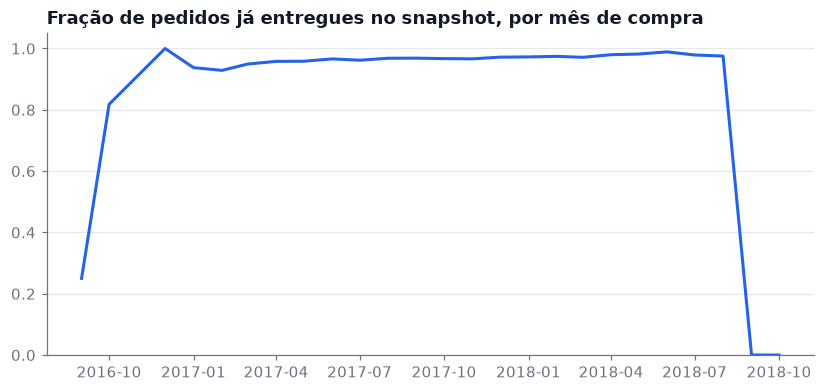

,fração delivered
purchase_month,
2018-05,0.982
2018-06,0.989
2018-07,0.979
2018-08,0.975
2018-09,0.000
2018-10,0.000


In [16]:
coverage = (
    orders.assign(
        purchase_month=orders["order_purchase_timestamp"].dt.to_period("M"),
        is_delivered=orders["order_status"].eq("delivered"),
    )
    .groupby("purchase_month")["is_delivered"]
    .mean()
)

fig, ax = plt.subplots()
ax.plot(coverage.index.to_timestamp(), coverage.values, color=ACCENT, linewidth=2)
ax.set_title("Fração de pedidos já entregues no snapshot, por mês de compra")
ax.set_ylim(0, 1.05)
plt.show()

coverage.tail(6).round(3).to_frame("fração delivered")

## 10. Conclusões e handoff para a etapa 2

**Estabelecido neste notebook:**

1. População: pedidos `delivered` com data de entrega (8 excluídos por data nula); alvo comparado por **datas**, com taxa de atraso medida de **~6,8%** (problema desbalanceado, acurácia proibida como métrica principal).
2. Schema verificado por código: `orders ↔ customers` é 1:1 (`customer_id` é por pedido); `geolocation` não tem chave e só entra agregada; `reviews` têm duplicatas e são 100% vazamento como feature.
3. **Contrato de vazamento** (seção 6): lista executável de colunas permitidas vs banidas, com motivo. Será verificado no notebook 03 com o teste do alvo embaralhado.
4. `shipping_limit_date`: validada e **excluída por prudência**, decisão registrada antes da modelagem.
5. Armadilhas de integridade quantificadas, cada uma com tratamento planejado para a tabela mestra.
6. Viés de sobrevivência na borda do período medido; o teste será truncado no notebook 03.

**Próximo passo (etapa 2):** `src/data_prep.py` constrói a tabela mestra em `data/processed/` (1 linha por pedido, joins auditados linha a linha, geolocation agregada em centroides), e o notebook 02 usa essa tabela para a EDA orientada a perguntas de negócio e a segmentação de vendedores.